# W01 — Baseline Profiling: MobileNetV3-Small on CIFAR-10

**Goal.** Profile an uncompressed baseline model end-to-end (parameters, FLOPs, weight-file size, single-sample CPU latency) and quantify the deployment gap against the Aido Rover constraints (< 5 MB, < 100 ms). These numbers serve as the "before" side of every compression experiment in Weeks 2–3 (Mars Trading 8-element standard).

**Model & dataset selection.** MobileNetV3-Small + CIFAR-10 (image classification), per the Week-1 selection criteria: (a) small enough for CPU-only experiments; (b) public dataset available via HuggingFace datasets; (c) importable as a pretrained PyTorch checkpoint. Image classification matches the Aido Rover onboard-perception deployment context.

**Environment.** Apple M-series CPU (macOS) · Python 3.13 · PyTorch 2.12.1 (CPU build) · seeds fixed at 42 for reproducibility.

In [1]:
# W01 Baseline Profiling — MobileNetV3-Small + CIFAR-10
# Reproducibility: fixed seeds (required by project plan §5.2)
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f"PyTorch {torch.__version__}, CPU threads: {torch.get_num_threads()}")

PyTorch 2.12.1, CPU threads: 4


## Metrics 1–2: Parameter count & FLOPs

Parameter count measures how many numbers the model stores (drives memory/size). FLOPs measure compute per single inference (drives latency). Both are measured with `torchinfo` on a `(1, 3, 224, 224)` input — the resolution these ImageNet-pretrained weights expect.

In [2]:
# Load MobileNetV3-Small with ImageNet pretrained weights (~10 MB download, cached after first run)
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.eval()
print(sum(p.numel() for p in model.parameters()), "parameters")

2542856 parameters


In [3]:
# Metric 2: FLOPs — computational cost per single inference (batch_size=1)
from torchinfo import summary

info = summary(model, input_size=(1, 3, 224, 224), verbose=0)
print(f"MACs: {info.total_mult_adds:,}")
print(f"FLOPs (≈ 2 × MACs): {2 * info.total_mult_adds:,}")

MACs: 56,527,424
FLOPs (≈ 2 × MACs): 113,054,848


## Metric 3: Weight-file size on disk

Platform budgets constrain the *file* that ships to the device, so we save the `state_dict` and measure the actual file — not `params × 4 bytes`, which misses non-parameter buffers (batch-norm running stats) and format overhead.

In [4]:
# Metric 3: model weight file size on disk (MB)
import os

torch.save(model.state_dict(), "mobilenetv3_small_fp32.pth")
size_mb = os.path.getsize("mobilenetv3_small_fp32.pth") / 1e6
print(f"FP32 weight file size: {size_mb:.2f} MB")

FP32 weight file size: 10.31 MB


## Metric 4: Single-sample CPU inference latency

Measured with `timeit`: batch_size = 1 (edge devices process sensor samples one at a time, unlike batched server inference), 10 untimed warm-up runs (exclude one-off allocation costs), then the mean of 100 timed runs (average out OS scheduling noise). A random tensor is sufficient — convolution runtime depends on tensor shape, not pixel content.

In [5]:
# Metric 4: CPU inference latency — single sample (batch_size=1), mean of 100 timed runs
import timeit

x = torch.randn(1, 3, 224, 224)   # one random "image": batch=1, 3 channels, 224x224

with torch.no_grad():
    for _ in range(10):            # warm-up runs (not timed)
        model(x)
    total = timeit.timeit(lambda: model(x), number=100)

latency_ms = total / 100 * 1000
print(f"Mean CPU latency (bs=1, 100 runs): {latency_ms:.2f} ms")

Mean CPU latency (bs=1, 100 runs): 40.46 ms


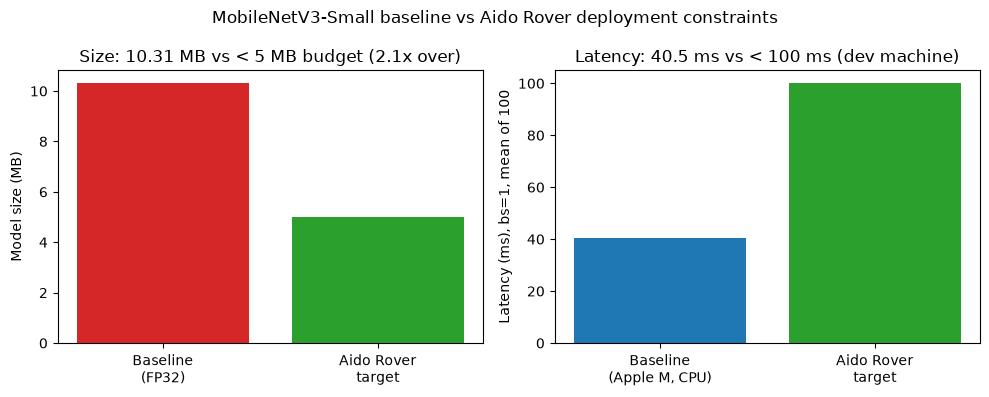

In [6]:
# Deployment gap: baseline vs Aido Rover targets (size & latency)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: model size
axes[0].bar(["Baseline\n(FP32)", "Aido Rover\ntarget"], [size_mb, 5.0], color=["#d62728", "#2ca02c"])
axes[0].set_ylabel("Model size (MB)")
axes[0].set_title(f"Size: {size_mb:.2f} MB vs < 5 MB budget ({size_mb/5:.1f}x over)")

# Right: latency
axes[1].bar(["Baseline\n(Apple M, CPU)", "Aido Rover\ntarget"], [latency_ms, 100.0], color=["#1f77b4", "#2ca02c"])
axes[1].set_ylabel("Latency (ms), bs=1, mean of 100")
axes[1].set_title(f"Latency: {latency_ms:.1f} ms vs < 100 ms (dev machine)")

plt.suptitle("MobileNetV3-Small baseline vs Aido Rover deployment constraints")
plt.tight_layout()
plt.savefig("../experiments/W01_deployment_gap.png", dpi=150, bbox_inches="tight")
plt.show()

## Results & deployment gap

| Metric | Baseline (FP32) | Aido Rover target | Status |
|---|---|---|---|
| Parameters | 2,542,856 | — | — |
| FLOPs (bs=1) | ≈113 M (56.5 M MACs) | — | — |
| Weight file size | **10.31 MB** | < 5 MB | ❌ 2.1× over budget |
| CPU latency (bs=1, mean of 100) | **40.46 ms** | < 100 ms | ✅ on dev machine — see caveat |

**Conclusion.** The primary deployment blocker for Aido Rover is **model size** (10.31 MB vs 5 MB, 2.1× over). Latency passes on the development machine, but this is an Apple M-series CPU — substantially faster than the Cortex-A-class embedded CPU targeted by Aido Rover, so the latency margin cannot be relied upon on real hardware.

**Next (Week 2).** INT8 post-training quantization stores each parameter in 1 byte instead of 4, projecting ≈ 10.31 / 4 ≈ 2.6 MB — within budget — with an expected latency benefit from SIMD integer arithmetic on ARM. Structured pruning will be swept 10–90% as the complementary technique.

In [7]:
# Sanity check: run one real image through the full pipeline.
# NOTE: the model has an ImageNet 1000-class head, which does not match
# CIFAR-10 classes — this cell only verifies the pipeline works, not accuracy.

from datasets import load_dataset
from torchvision import transforms
import torch

# Take one test image from the CIFAR-10 dataset we already cached
ds = load_dataset('uoft-cs/cifar10', split='test')
img = ds[0]['img']          # a PIL image, 32x32
print("CIFAR-10 label:", ds.features['label'].names[ds[0]['label']])

# Preprocess to what the ImageNet-pretrained model expects
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
x = preprocess(img).unsqueeze(0)   # shape: (1, 3, 224, 224)

# Inference
with torch.no_grad():
    logits = model(x)
top1 = logits.argmax(dim=1).item()
print("Pipeline OK — model output shape:", logits.shape)
print("Predicted ImageNet class index:", top1)

CIFAR-10 label: cat
Pipeline OK — model output shape: torch.Size([1, 1000])
Predicted ImageNet class index: 335
